# Planteamiento del Problema:
El conjunto de datos se compone de fotos de perros y gatos proporcionadas como un subconjunto de fotos de uno mucho más grande de 3 millones de fotos anotadas manualmente. Estos datos se obtuvieron a través de una colaboración entre Petfinder.com y Microsoft.

El conjunto de datos se usó originalmente como un CAPTCHA, es decir, una tarea que se cree que un humano encuentra trivial, pero que una máquina no puede resolver, que se usa en sitios web para distinguir entre usuarios humanos y bots. La tarea se denominó "Asirra". Cuando se presentó "Asirra", se mencionó "que los estudios de usuarios indican que los humanos pueden resolverlo el 99,6% de las veces en menos de 30 segundos". A menos que se produzca un gran avance en la visión artificial, esperamos que los ordenadores no tengan más de 1/54.000 posibilidades de resolverlo.

En el momento en que se publicó la competencia, el resultado de última generación se logró con un SVM y se describió en un artículo de 2007 con el título "Ataques de Machine Learning contra el CAPTCHA de Asirra" (PDF) que logró una precisión de clasificación del 80%. Fue este documento el que demostró que la tarea ya no era una tarea adecuada para un CAPTCHA poco después de que se propusiera la tarea.

## Paso 1: Carga del conjunto de datos
- Las 25.000 imágenes de perros y gatos están en una única carpeta `train/`, con nombres de archivo tipo `cat.0.jpg`, `dog.0.jpg`, etc. (formato estándar del dataset de Kaggle "Dogs vs Cats").
- **IMPORTANTE**: como la máquina tiene 8 GB de RAM (≤ 12 GB), en vez de cargar las 25.000 imágenes en memoria de golpe, usamos la clase `ImageDataGenerator` de Keras junto con `flow_from_directory()`, que carga las imágenes progresivamente desde disco por lotes (batches). Esta función necesita que los datos estén organizados en subcarpetas por clase dentro de `train/` y `test/`, así que primero reorganizamos los archivos.

## Paso 2: Visualiza la información de entrada
- Cargamos e imprimimos las primeras nueve fotos de perros en una sola figura. Repetimos lo mismo para los gatos. Se puede ver que las fotos son a color y tienen diferentes formas y tamaños.


In [1]:
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array


I0000 00:00:1787928094.625202    1312 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787928094.736522    1312 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787928114.311937    1312 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787928132.191313    1312 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

In [2]:
# Ruta a la carpeta con las 25.000 imágenes sueltas
raw_dir = "/workspaces/Deep_Learning_Sahid_Leal/data/raw/imagen"

# Comprobamos que la ruta existe y mostramos cuántos archivos hay
assert os.path.isdir(raw_dir), f"No se encuentra la carpeta: {raw_dir}"
all_files = os.listdir(raw_dir)
print(f"Total de archivos encontrados: {len(all_files)}")
print("Ejemplos:", all_files[:5])


Total de archivos encontrados: 23262
Ejemplos: ['dog.6653.jpg', 'cat.538.jpg', 'dog.9390.jpg', 'cat.1320.jpg', 'dog.783.jpg']


In [3]:
# Separamos los nombres de archivo por clase según el prefijo del nombre (cat./dog.)
cat_files = [f for f in all_files if f.lower().startswith("cat")]
dog_files = [f for f in all_files if f.lower().startswith("dog")]

print(f"Gatos: {len(cat_files)} | Perros: {len(dog_files)}")


Gatos: 11658 | Perros: 11604


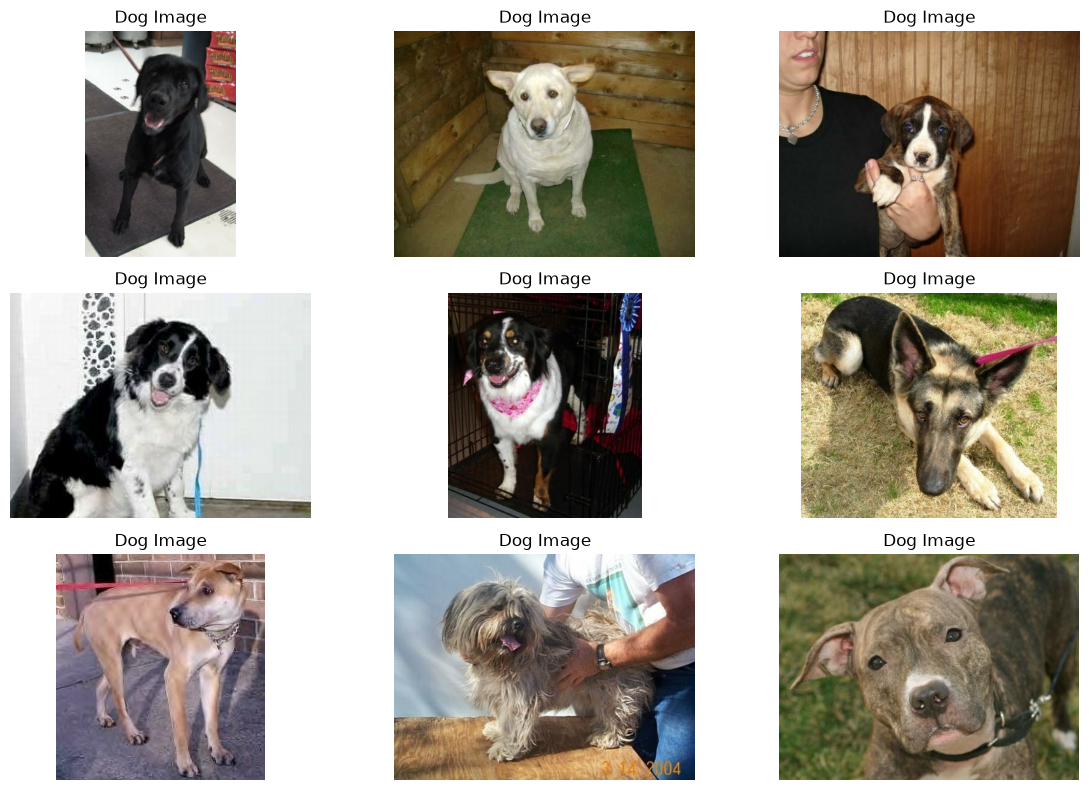

In [4]:
# Visualizar las primeras 9 fotos de perros
dog_images = []
for fname in dog_files[:9]:
    img_path = os.path.join(raw_dir, fname)
    img = load_img(img_path)
    img_array = img_to_array(img)
    img_array /= 255.0
    dog_images.append(img_array)

plt.figure(figsize=(12, 8))
for i, img_array in enumerate(dog_images):
    plt.subplot(3, 3, i + 1)
    plt.imshow(img_array)
    plt.title("Dog Image")
    plt.axis("off")
plt.tight_layout()
plt.show()


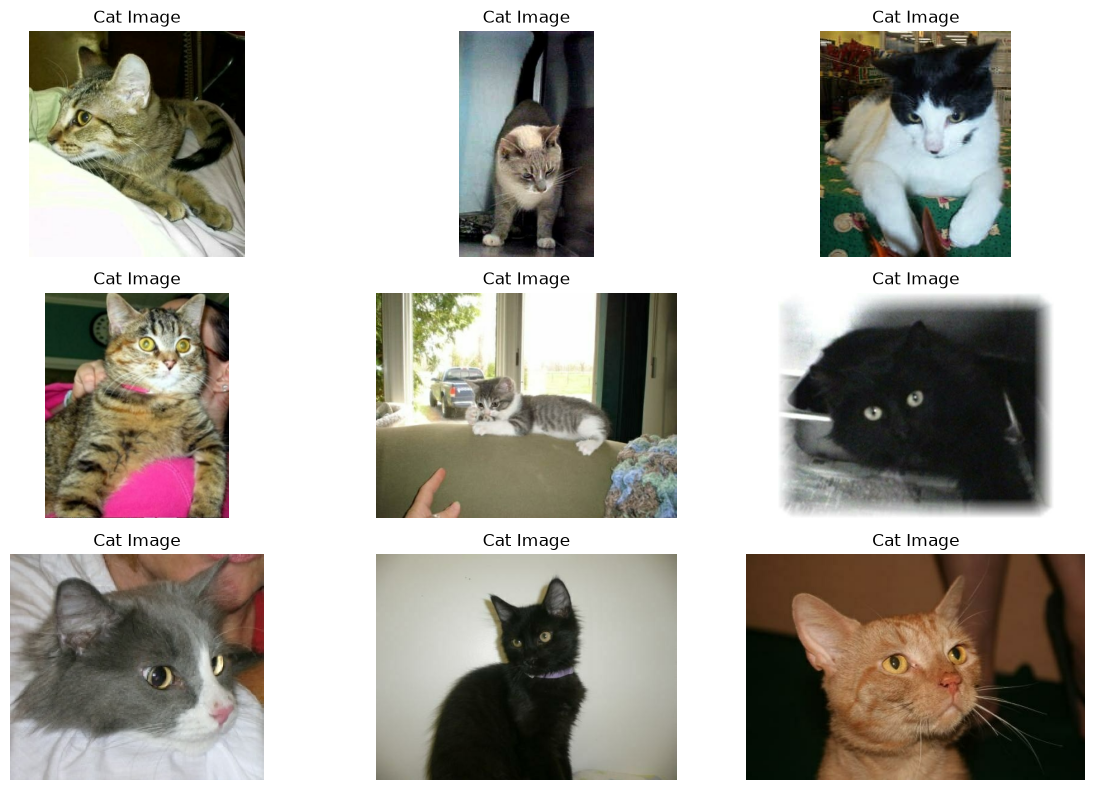

In [5]:
# Visualizar las primeras 9 fotos de gatos
cat_images = []
for fname in cat_files[:9]:
    img_path = os.path.join(raw_dir, fname)
    img = load_img(img_path)
    img_array = img_to_array(img)
    img_array /= 255.0
    cat_images.append(img_array)

plt.figure(figsize=(12, 8))
for i, img_array in enumerate(cat_images):
    plt.subplot(3, 3, i + 1)
    plt.imshow(img_array)
    plt.title("Cat Image")
    plt.axis("off")
plt.tight_layout()
plt.show()


- Reorganizamos las imágenes en subcarpetas por clase (train/test)


In [6]:
processed_dir = "/workspaces/Deep_Learning_Sahid_Leal/data/processed"
split_ratio = 0.8  # 80% train, 20% test
random.seed(42)

for split in ["train", "test"]:
    for cls in ["cat", "dog"]:
        os.makedirs(os.path.join(processed_dir, split, cls), exist_ok=True)

def split_and_copy(files, cls_name):
    files_shuffled = files.copy()
    random.shuffle(files_shuffled)
    n_train = int(len(files_shuffled) * split_ratio)
    train_files = files_shuffled[:n_train]
    test_files = files_shuffled[n_train:]

    for fname in train_files:
        src = os.path.join(raw_dir, fname)
        dst = os.path.join(processed_dir, "train", cls_name, fname)
        if not os.path.exists(dst):
            shutil.copyfile(src, dst)

    for fname in test_files:
        src = os.path.join(raw_dir, fname)
        dst = os.path.join(processed_dir, "test", cls_name, fname)
        if not os.path.exists(dst):
            shutil.copyfile(src, dst)

    return len(train_files), len(test_files)

n_train_cat, n_test_cat = split_and_copy(cat_files, "cat")
n_train_dog, n_test_dog = split_and_copy(dog_files, "dog")

print(f"Gatos -> train: {n_train_cat}, test: {n_test_cat}")
print(f"Perros -> train: {n_train_dog}, test: {n_test_dog}")


Gatos -> train: 9326, test: 2332
Perros -> train: 9283, test: 2321


- Creamos los generadores de datos (`ImageDataGenerator` + `flow_from_directory`)
Redimensionamos todas las imágenes a 200x200 píxeles y normalizamos los valores de píxel a [0,1]. Las etiquetas se asignan automáticamente según el nombre de la subcarpeta (`cat`/`dog`).

In [7]:
IMG_SIZE = (160, 160)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(rescale=1.0/255.0)
test_datagen = ImageDataGenerator(rescale=1.0/255.0)

trdata = train_datagen.flow_from_directory(
    os.path.join(processed_dir, "train"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
)

tsdata = test_datagen.flow_from_directory(
    os.path.join(processed_dir, "test"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False,
)

print("Mapeo de clases:", trdata.class_indices)

Found 18609 images belonging to 2 classes.
Found 4653 images belonging to 2 classes.
Mapeo de clases: {'cat': 0, 'dog': 1}


# Paso 3: Construimos una RNA

In [8]:
from keras.applications import EfficientNetB0
from keras.models import Sequential
from keras.layers import Dense, GlobalAveragePooling2D

model = Sequential()
model.add(EfficientNetB0(include_top=False, weights="imagenet", input_shape=(*IMG_SIZE, 3)))
model.layers[0].trainable = False
model.add(GlobalAveragePooling2D())
model.add(Dense(units=128, activation="relu"))
model.add(Dense(units=2, activation="softmax"))

model.summary()


E0000 00:00:1787928157.862822    1312 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 5, 5, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,797 (16.07 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

### Compilamos el modelo

In [9]:
model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"],)

### Aviso sobre el tiempo de entrenamiento
Por los logs de la celda de imports (`GPU will not be used`), TensorFlow está entrenando en **CPU**. Entrenar EfficientNet-B0 **desde cero** (`weights=None`) sobre ~18.600 imágenes en CPU es lento (varios minutos por época es normal). Usamos `EarlyStopping` para cortar si deja de mejorar, y empezamos con pocas épocas para validar que el pipeline funciona antes de lanzar un entrenamiento largo.

In [10]:
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

EPOCHS = 2
STEPS_PER_EPOCH = min(200, len(trdata))
VALIDATION_STEPS = min(50, len(tsdata))

history = model.fit(
    trdata,
    validation_data=tsdata,
    epochs=EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_steps=VALIDATION_STEPS,
    callbacks=[early_stop],
)

Epoch 1/2


I0000 00:00:1787928172.170127    1312 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


200/200 ━━━━━━━━━━━━━━━━━━━━ 184s 862ms/step - accuracy: 0.4989 - loss: 0.7017 - val_accuracy: 1.0000 - val_loss: 0.6870
Epoch 2/2
200/200 ━━━━━━━━━━━━━━━━━━━━ 112s 561ms/step - accuracy: 0.4882 - loss: 0.6937 - val_accuracy: 0.0000e+00 - val_loss: 0.6973


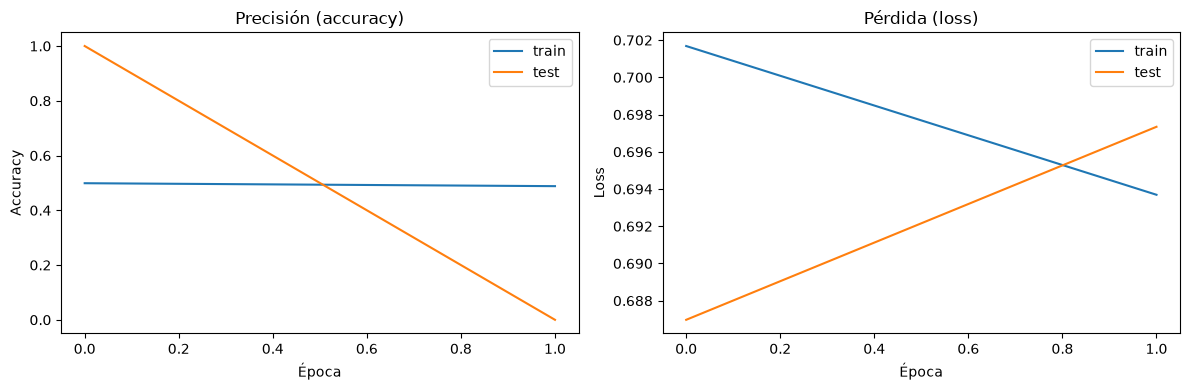

In [11]:
if not history.history.get("accuracy"):
    raise RuntimeError("No hay datos de entrenamiento. Ejecuta de nuevo la celda model.fit completa.")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="test")
plt.title("Precisión (accuracy)")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="test")
plt.title("Pérdida (loss)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
test_loss, test_acc = model.evaluate(tsdata)
print(f"Pérdida en test: {test_loss:.4f}")
print(f"Precisión en test: {test_acc:.4f}")


146/146 ━━━━━━━━━━━━━━━━━━━━ 69s 471ms/step - accuracy: 0.5012 - loss: 0.6931
Pérdida en test: 0.6931
Precisión en test: 0.5012


- Precisión del 50.12%: Significa que acierta la mitad de las veces y falla la otra mitad.
- Pérdida (Loss) de 0.6932: indica que el modelo no ha logrado reducir el error general respecto al punto de partida.
## Paso 4: Optimizamos el modelo anterior

In [13]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix

# Guardar el checkpoint fuera de la carpeta del notebook
model_path = os.path.join("/workspaces/Deep_Learning_Sahid_Leal","models","mejor_modelo.keras",)
os.makedirs(os.path.dirname(model_path), exist_ok=True)

checkpoint = ModelCheckpoint(filepath=model_path,monitor="val_loss",save_best_only=True,mode="min",verbose=1,)

early_stopping = EarlyStopping(monitor="val_loss",patience=3,restore_best_weights=True,verbose=1,)

# En Keras actual, fit reemplaza al antiguo fit_generator.
# Limitamos los batches para que la prueba sea viable en CPU.
OPTIMIZED_EPOCHS = 4
OPTIMIZED_STEPS = min(200, len(trdata))
OPTIMIZED_VALIDATION_STEPS = min(50, len(tsdata))

history_optimized = model.fit(trdata,epochs=OPTIMIZED_EPOCHS,steps_per_epoch=OPTIMIZED_STEPS,validation_data=tsdata,validation_steps=OPTIMIZED_VALIDATION_STEPS,callbacks=[checkpoint, early_stopping],)

# Cargar el checkpoint con el mejor val_loss
best_model = load_model(model_path)

# Generar predicciones sobre todo el conjunto de test
test_steps = len(tsdata)
tsdata.reset()
prediction_probabilities = best_model.predict(tsdata, steps=test_steps, verbose=1)
predicted_labels = np.argmax(prediction_probabilities, axis=1)
true_labels = tsdata.classes[:len(predicted_labels)]
class_names = list(tsdata.class_indices.keys())

print("Matriz de confusión:")
print(confusion_matrix(true_labels, predicted_labels))
print("\nInforme de clasificación:")
print(classification_report(true_labels, predicted_labels, target_names=class_names))

Epoch 1/4
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.4915 - loss: 0.6933
Epoch 1: val_loss improved from None to 0.69410, saving model to /workspaces/Deep_Learning_Sahid_Leal/models/mejor_modelo.keras

Epoch 1: finished saving model to /workspaces/Deep_Learning_Sahid_Leal/models/mejor_modelo.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 113s 564ms/step - accuracy: 0.4915 - loss: 0.6933 - val_accuracy: 0.0000e+00 - val_loss: 0.6941
Epoch 2/4
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.4902 - loss: 0.6932
Epoch 2: val_loss did not improve from 0.69410
200/200 ━━━━━━━━━━━━━━━━━━━━ 123s 614ms/step - accuracy: 0.4902 - loss: 0.6932 - val_accuracy: 0.0000e+00 - val_loss: 0.6994
Epoch 3/4
182/200 ━━━━━━━━━━━━━━━━━━━━ 7s 438ms/step - accuracy: 0.5021 - loss: 0.6932

/home/vscode/.local/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 3: val_loss improved from 0.69410 to 0.68868, saving model to /workspaces/Deep_Learning_Sahid_Leal/models/mejor_modelo.keras

Epoch 3: finished saving model to /workspaces/Deep_Learning_Sahid_Leal/models/mejor_modelo.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 108s 538ms/step - accuracy: 0.5021 - loss: 0.6932 - val_accuracy: 1.0000 - val_loss: 0.6887
Epoch 4/4
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.4993 - loss: 0.6932
Epoch 4: val_loss did not improve from 0.68868
200/200 ━━━━━━━━━━━━━━━━━━━━ 133s 661ms/step - accuracy: 0.4993 - loss: 0.6932 - val_accuracy: 0.0000e+00 - val_loss: 0.6956
Restoring model weights from the end of the best epoch: 3.
146/146 ━━━━━━━━━━━━━━━━━━━━ 69s 463ms/step
Matriz de confusión:
[[2332    0]
 [2321    0]]

Informe de clasificación:
              precision    recall  f1-score   support

         cat       0.50      1.00      0.67      2332
         dog       0.00      0.00      0.00      2321

    accuracy                           0.50     

/home/vscode/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/vscode/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/vscode/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## Paso 5: Guardamos el modelo

In [14]:
# Asegurarse de que el directorio de modelos existe
os.makedirs("/workspaces/Deep_Learning_Sahid_Leal/models", exist_ok=True)

# Ruta completa donde se guardará el modelo final
model_save_path = "/workspaces/Deep_Learning_Sahid_Leal/models/dogs_vs_cats_model.keras"

# Guardar el modelo entrenado (asumiendo que tu variable de modelo se llama 'model')
model.save(model_save_path)

print(f"Modelo guardado exitosamente en: {model_save_path}")

Modelo guardado exitosamente en: /workspaces/Deep_Learning_Sahid_Leal/models/dogs_vs_cats_model.keras
